# Customer Experience Impact Analysis

**Business question:** How is delivery performance associated with customer review outcomes?

This notebook focuses on four questions:

1. **Are missing reviews informative?**
2. **How different are review outcomes for early, on-time, and late deliveries?**
3. **Does customer dissatisfaction increase as delay severity increases?**
4. **Does the late-delivery review gap persist across important customer/order segments?**

All review scores, delivery classes, and delay measures come from the certified KPI layer. Missing reviews remain missing. Results are associations, not causal effects.


In [2]:
from pathlib import Path
import sys

%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

from python.scripts.config import ANALYSIS_OUTPUT_DIR
from python.scripts.customer_experience import DELAY_LABELS

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

coverage = pd.read_csv(ANALYSIS_OUTPUT_DIR / "review_coverage.csv")
rates = pd.read_csv(ANALYSIS_OUTPUT_DIR / "delivery_class_review_rates.csv")
delay = pd.read_csv(ANALYSIS_OUTPUT_DIR / "delay_band_reviews.csv")
selection = pd.read_csv(ANALYSIS_OUTPUT_DIR / "review_selection.csv")
segments = pd.read_csv(ANALYSIS_OUTPUT_DIR / "segment_review_performance.csv")
sensitivity = pd.read_csv(ANALYSIS_OUTPUT_DIR / "cx_delay_sensitivity.csv")

all_orders = coverage.set_index("population").loc["all_orders"]
delivered = coverage.set_index("population").loc["delivered_orders"]

print(f"Reviewed orders: {int(all_orders.reviewed_orders):,} / {int(all_orders.orders):,}")
print(f"Delivered review coverage: {delivered.review_coverage:.2%}")
print(f"Overall negative review rate: {all_orders.negative_review_rate:.2%}")


Reviewed orders: 97,530 / 99,441
Delivered review coverage: 98.24%
Overall negative review rate: 14.56%


## 1. Are missing reviews informative?

Review coverage is high, but missing reviews are not random noise.

Comparing reviewed and unreviewed delivered orders tells us whether the observed review sample represents the full delivered population equally well.


,delivered_orders,eligible_orders,late_orders,late_delivery_rate,repeat_share,median_gmv
review_availability,,,,,,
reviewed,94782,94774,6307,0.067,0.028,86.900
unreviewed,1696,1696,227,0.134,0.331,80.595


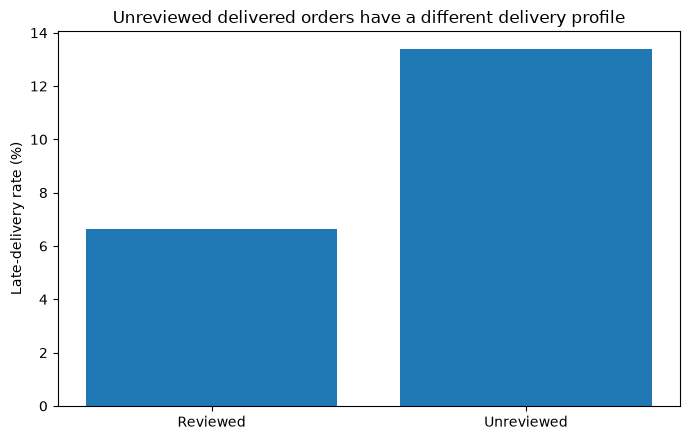

In [3]:
selection_view = selection.set_index("review_availability")[
    ["delivered_orders", "eligible_orders", "late_orders", "late_delivery_rate", "repeat_share", "median_gmv"]
]
display(selection_view)

fig, ax = plt.subplots(figsize=(7, 4.5))
values = selection_view.loc[["reviewed", "unreviewed"], "late_delivery_rate"] * 100
ax.bar(["Reviewed", "Unreviewed"], values)
ax.set(
    title="Unreviewed delivered orders have a different delivery profile",
    ylabel="Late-delivery rate (%)",
)
fig.tight_layout()
plt.show()


## 2. How strongly is delivery outcome associated with reviews?

The useful comparison is not simply the overall negative-review rate. It is whether customer sentiment changes materially across **early, on-time, and late** deliveries.

This is the clearest customer-impact view in the analysis.


,reviewed_orders,negative_review_orders,negative_review_rate,avg_review_score
delivery_class,,,,
early,87203,7945,0.091,4.298
on_time,1264,155,0.123,4.040
late,6307,3932,0.623,2.272


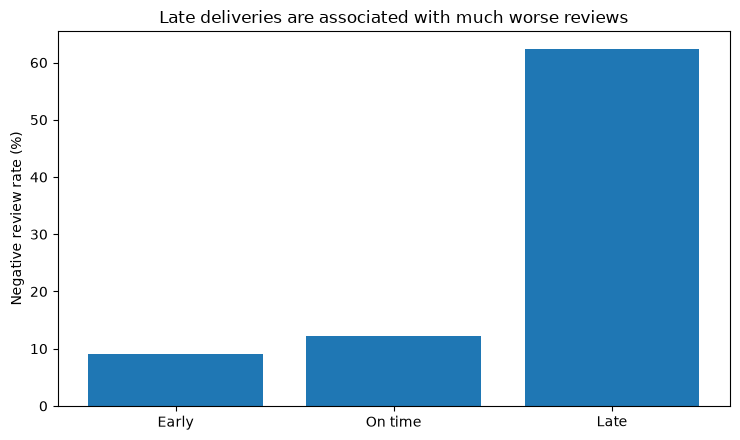

In [4]:
class_view = (
    rates.set_index("delivery_class")
    .loc[["early", "on_time", "late"], [
        "reviewed_orders",
        "negative_review_orders",
        "negative_review_rate",
        "avg_review_score",
    ]]
)
display(class_view)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.bar(
    ["Early", "On time", "Late"],
    class_view["negative_review_rate"] * 100,
)
ax.set(
    title="Late deliveries are associated with much worse reviews",
    ylabel="Negative review rate (%)",
)
fig.tight_layout()
plt.show()


## 3. Does severity matter?

A binary late/not-late label can hide an important operational pattern.

If negative reviews rise as deliveries move from slightly late to severely late, then **delay magnitude** matters—not just whether the promise was missed.


,reviewed_orders,negative_review_orders,negative_review_rate,avg_review_score
label,,,,
15+ days early,34330,3061,0.089,4.328
8–14 days early,35778,3157,0.088,4.314
4–7 days early,12433,1212,0.097,4.231
1–3 days early,4662,515,0.110,4.139
On time,1264,155,0.123,4.040
1–3 days late,1833,586,0.320,3.296
4–7 days late,1731,1169,0.675,2.107
8–14 days late,1431,1149,0.803,1.667
15–30 days late,990,809,0.817,1.612


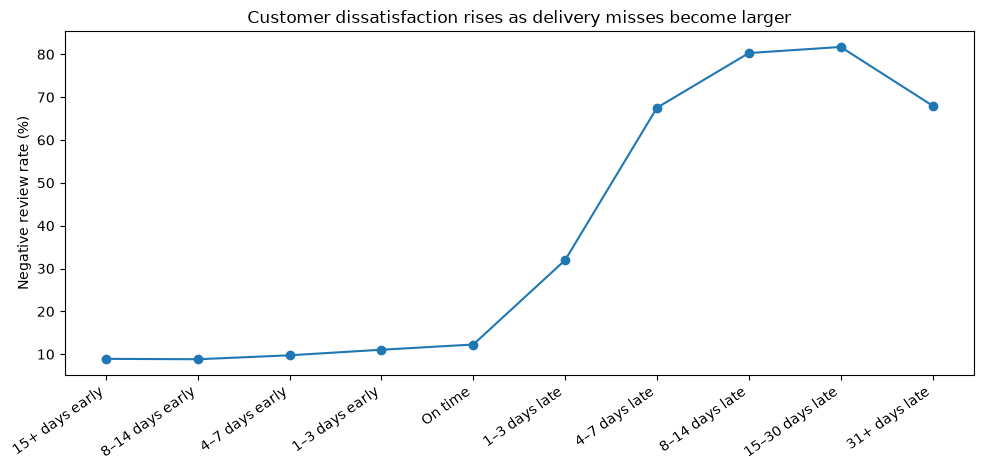

In [ ]:
delay_view = delay.sort_values("delay_band_sort").copy()
delay_view["label"] = delay_view["delay_band"].map(DELAY_LABELS)

display(
    delay_view.set_index("label")[
        ["reviewed_orders", "negative_review_orders", "negative_review_rate", "avg_review_score"]
    ]
)

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(
    range(len(delay_view)),
    delay_view["negative_review_rate"] * 100,
    marker="o",
)
ax.set_xticks(
    range(len(delay_view)),
    delay_view["label"],
    rotation=35,
    ha="right",
)
ax.set(
    title="Negative reviews rise sharply once deliveries miss the promise and remain very high for severe delays",
    ylabel="Negative review rate (%)",
)
fig.tight_layout()
plt.show()


## 4. Does the relationship persist across key segments?

A useful customer-experience finding should not disappear after one obvious split.

Rather than creating separate sections for every segment, compare the **late-versus-early negative-review gap** across:

- first vs repeat purchases;
- order-value bands;
- major customer states;
- sufficiently sized product categories.

This is a descriptive consistency check, not a statistical adjustment.


,groups,median_gap_pp,min_gap_pp,max_gap_pp
segment_type,,,,
customer_state,24,53.891,36.752,67.704
product_category,52,53.445,25.744,86.301
gmv_band,4,52.890,52.652,53.943
purchase_sequence,2,51.382,49.454,53.311


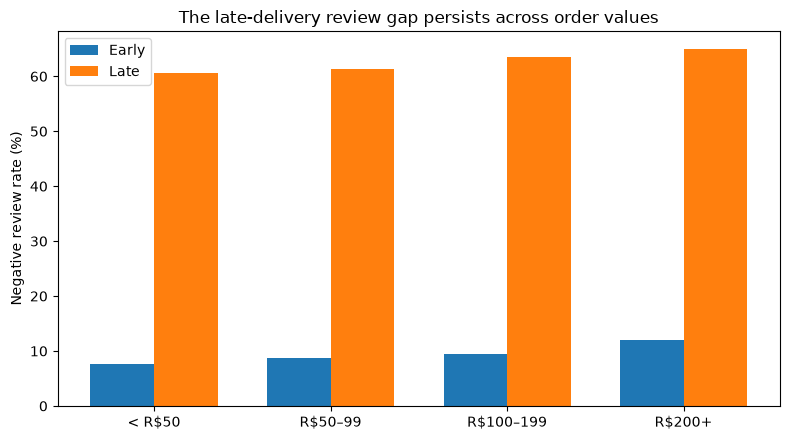

In [6]:
segment_gap = segments.copy()
segment_gap["review_gap_pp"] = (
    segment_gap["late_negative_review_rate"]
    - segment_gap["early_negative_review_rate"]
) * 100

summary = (
    segment_gap[~segment_gap["is_low_sample"]]
    .groupby("segment_type")
    .agg(
        groups=("segment_key", "count"),
        median_gap_pp=("review_gap_pp", "median"),
        min_gap_pp=("review_gap_pp", "min"),
        max_gap_pp=("review_gap_pp", "max"),
    )
    .sort_values("median_gap_pp", ascending=False)
)

display(summary)

gmv = (
    segment_gap[segment_gap["segment_type"] == "gmv_band"]
    .sort_values("segment_sort")
)

fig, ax = plt.subplots(figsize=(8, 4.5))
x = range(len(gmv))
ax.bar(
    [i - 0.18 for i in x],
    gmv["early_negative_review_rate"] * 100,
    width=0.36,
    label="Early",
)
ax.bar(
    [i + 0.18 for i in x],
    gmv["late_negative_review_rate"] * 100,
    width=0.36,
    label="Late",
)
ax.set_xticks(list(x), ["< R$50", "R$50–99", "R$100–199", "R$200+"])
ax.set(
    title="The late-delivery review gap persists across order values",
    ylabel="Negative review rate (%)",
)
ax.legend()
fig.tight_layout()
plt.show()


## Robustness check

Extreme delays could exaggerate the late-delivery review relationship.

The sensitivity analysis therefore compares the full eligible population with versions that remove the longest-delay tail.


In [7]:
late_sensitivity = (
    sensitivity[sensitivity["delivery_class"] == "late"]
    .set_index("slice")[
        ["reviewed_orders", "negative_review_orders", "negative_review_rate"]
    ]
)
display(late_sensitivity)


,reviewed_orders,negative_review_orders,negative_review_rate
slice,,,
all_eligible,6307,3932,0.623
exclude_late_31plus,5985,3713,0.620
exclude_p99_delay,5402,3226,0.597


## Takeaways

- **Late delivery is strongly associated with negative reviews.**
- **Delay magnitude matters:** Delay severity matters: negative-review rates rise sharply after the promised date and remain elevated for severe delays.
- **The relationship is not explained by order value alone** and remains visible across multiple customer/order segments.
- **Review missingness is informative:** unreviewed delivered orders have a different delivery profile, so observed reviews should not be treated as a perfectly random sample.
- **Extreme delays amplify the pattern but do not create it.**

The analysis supports the business conclusion that delivery reliability is closely linked with customer experience, while preserving an important limitation: these are observational associations and do not estimate the causal effect of lateness on reviews.
